In [1]:
import pickle
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
from sklearn import metrics

In [2]:
with open("H-HAN_mu60_10k_events_TRACKS.pkl", "rb") as f:
    data = pickle.load(f)

In [3]:
PhyGHT_true = []
PhyGHT_pred = []
for i in range(len(data)):
    PhyGHT_true.append(data[i]["gt_label"])
    PhyGHT_pred.append(data[i]["pred_score"])

In [4]:
PhyGHT_true = np.array(ak.ravel(PhyGHT_true).to_list())
PhyGHT_pred = np.array(ak.ravel(PhyGHT_pred).to_list())

In [5]:
with open("PUPPI_scores.pkl", "rb") as f:
    data = pickle.load(f)

In [6]:
PUPPI_true=np.array(data["true_scores"])
PUPPI_pred=np.array(data["pred_scores"])

In [7]:
def roc(y_pred,y_true):
    sig = y_true==1
    bkg = y_true==0
    
    sig_eff = []
    bkg_eff = []
    
    for threshold in np.linspace(-0.00001,0.99,100):
        
        sig_eff.append((np.sum(y_pred[sig] > threshold)) / len(y_true[sig]))
        bkg_eff.append(1-(np.sum(y_pred[bkg] < threshold)  / len(y_true[bkg])))

        #print("Theshold: ", threshold)
        #print("Signal Efficiency: ", sig_eff[-1])
        #print("Background Efficiency: ", bkg_eff[-1],"\n")
        
    bkg_rej = [1/x for x in bkg_eff]
    return np.array(sig_eff), np.array(bkg_rej)

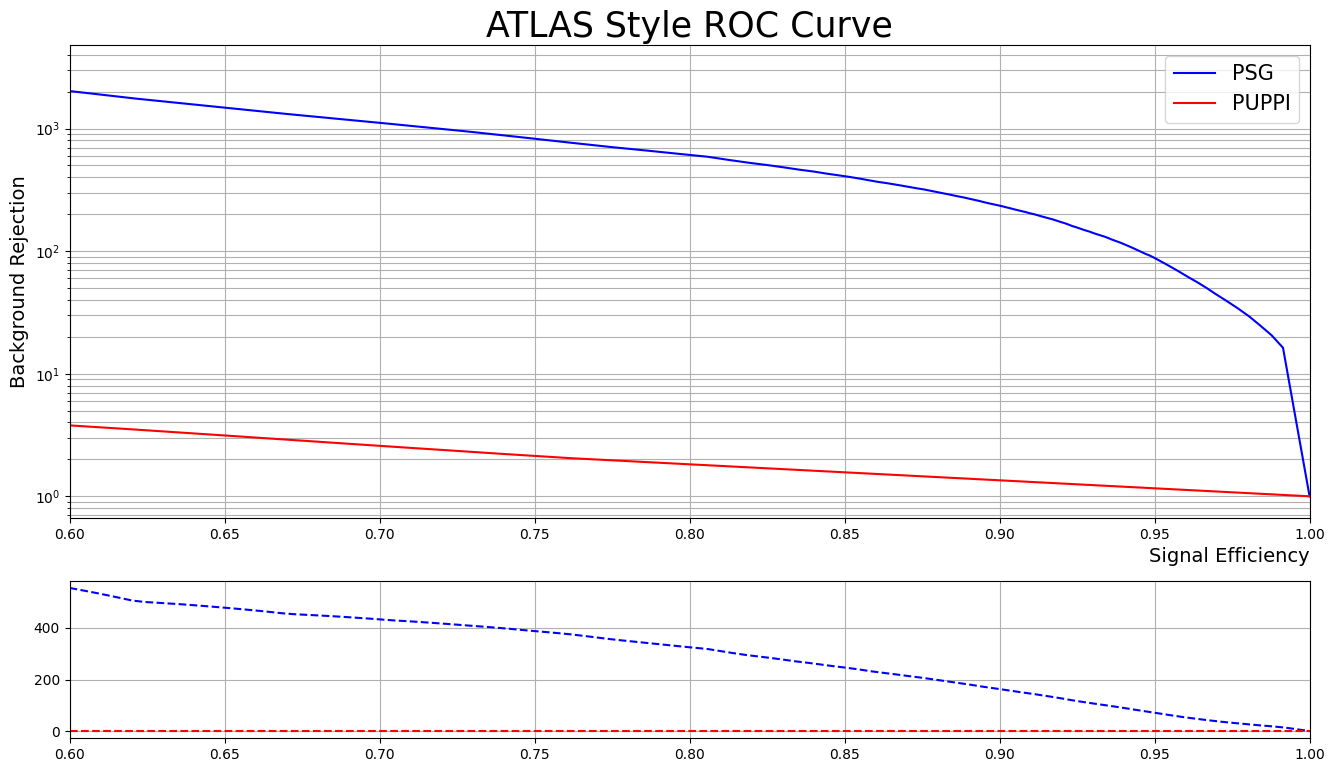

In [8]:
x1,y1 = roc(PhyGHT_pred,PhyGHT_true)
x2,y2 = roc(PUPPI_pred,PUPPI_true)

fig, (ax1, ax2) = plt.subplots(2,1,figsize=(16,9), gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(x1,y1,label='PSG',color='b')
ax1.plot(x2,y2,label='PUPPI',color='r')
ax1.set_title('ATLAS Style ROC Curve')
ax1.title.set_size(25)
ax1.legend(prop={'size': 15})
ax1.set_yscale('log')
ax1.set_xlim([0.6, 1])
ax1.set_xlabel('Signal Efficiency',loc='right', fontsize=14)
ax1.set_ylabel('Background Rejection',loc='center', fontsize=14)

x = 1-np.flip(np.linspace(0,0.4,100))
ratio1 = np.interp(x,np.flip(x1),np.flip(y1))/np.interp(x,np.flip(x2),np.flip(y2))
ratio2 = np.interp(x,np.flip(x2),np.flip(y2))/np.interp(x,np.flip(x2),np.flip(y2))

ax2.plot(x,ratio1,linestyle='--',color='b')
ax2.plot(x,ratio2,linestyle='--',color='r')
ax2.set_xlim([0.6, 1])

ax1.grid(which='both')
ax2.grid(which='both')
plt.show()

In [20]:
fpr1, tpr1, thresholds1 = metrics.roc_curve(PhyGHT_true, PhyGHT_pred)
fpr2, tpr2, thresholds2 = metrics.roc_curve(PUPPI_true, PUPPI_pred)

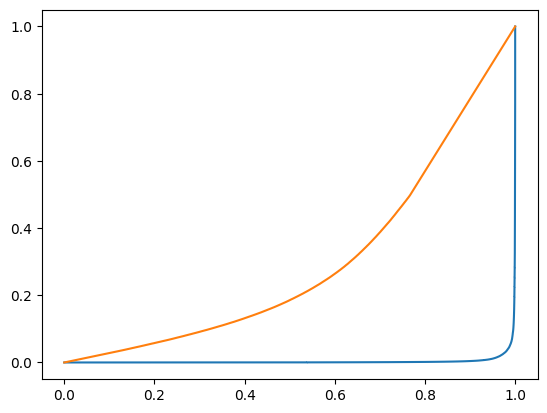

In [21]:
plt.plot(tpr1,fpr1)
plt.plot(tpr2,fpr2)
plt.show()

In [22]:
print(fpr2, tpr2, thresholds2)

[0.         0.01682928 0.01708399 ... 0.49822312 0.49822524 1.        ] [0.         0.05927059 0.06021418 ... 0.7670231  0.7670231  1.        ] [           inf 1.00000000e+00 1.00000000e+00 ... 3.17098578e-06
 1.60585832e-07 0.00000000e+00]


In [24]:
with open("PUPPI_ROC.pkl","wb") as f:
    data = {"tpr": tpr2, "fpr": fpr2, "thresholds": thresholds2}
    pickle.dump(data, f)